### [Why You Must Never Shuffle Financial Data](https://medium.com/@simplifiedzone/97fa22638d1d)

> Understanding time series, volatility clustering, and stationarity

In [1]:
!pip install -qq yfinance statsmodels

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings('ignore')

,0
2022-10-31,208.538127
2017-01-31,127.867316
2019-06-30,151.625317
2018-04-30,134.951424
2016-02-29,125.536281
2017-04-30,120.891547
2022-05-31,180.932539
2020-01-31,158.592070
2016-06-30,101.488790
2019-05-31,157.438085


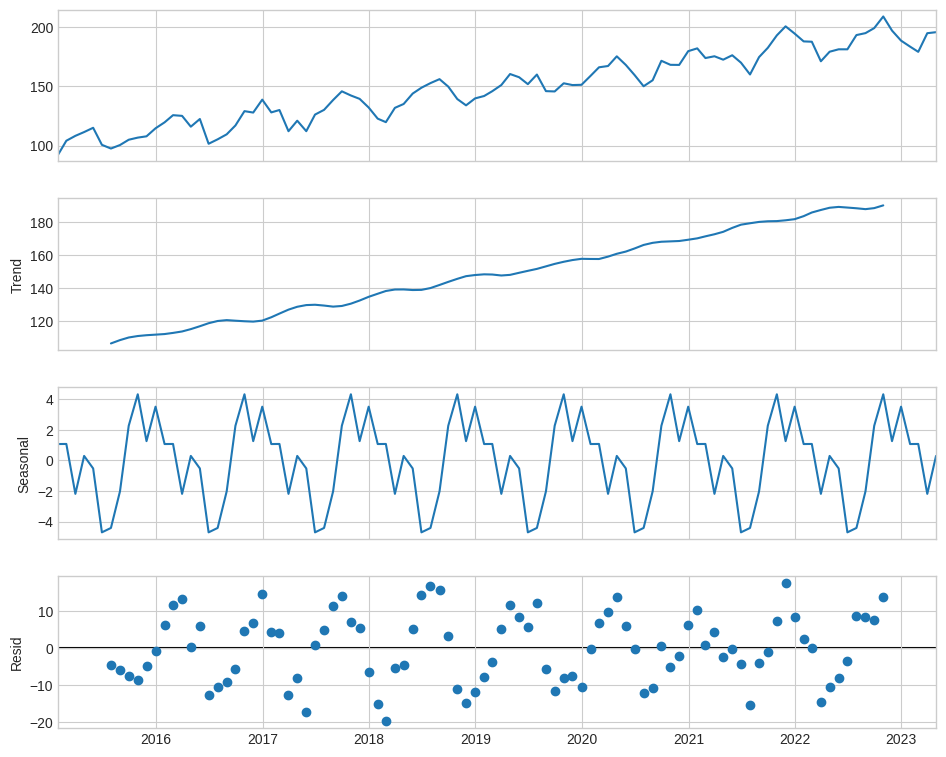

In [3]:
# Generate synthetic Monthly Data (Trend + Seasonality + Noise)
dates = pd.date_range(start='2015-01-01', periods=100, freq='M')
trend = np.linspace(100, 200, 100) # Upward trend
seasonality = np.sin(np.linspace(0, 20*np.pi, 100)) * 10 # Yearly wave
noise = np.random.normal(0, 5, 100) # Random noise

sales_data = pd.Series(trend + seasonality + noise, index=dates)

display(sales_data.sample(10))

# Decompose
# model='additive' assumes Data = Trend + Season + Noise
result = seasonal_decompose(sales_data, model='additive')

# Plot the 4 charts
fig = result.plot()
fig.set_size_inches(10, 8)
plt.show()

Ticker,MSFT
Date,
2020-04-16,168.555313
2023-08-16,315.053589
2020-08-18,201.915070
2020-08-10,198.821747
2022-07-13,245.603882
2020-01-30,164.051392
2021-11-15,324.581818
2023-05-22,315.153351
2023-06-05,329.636353


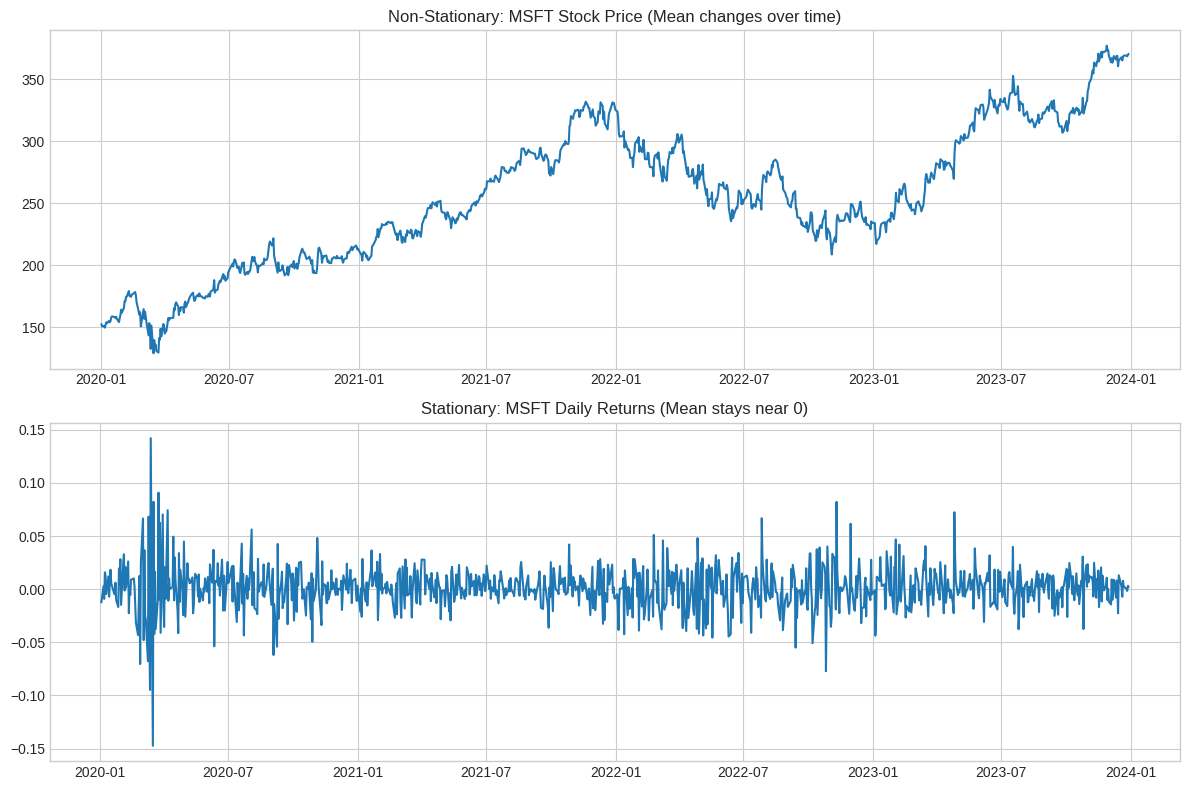

In [4]:
# Fetch Real Data (Microsoft)
msft = yf.download('MSFT', start='2020-01-01', end='2023-12-31', progress=False)['Close']

display(msft.sample(10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Prices (Non-Stationary)
ax1.plot(msft)
ax1.set_title("Non-Stationary: MSFT Stock Price (Mean changes over time)")

# Plot 2: Returns (Stationary)
# Differencing: Price(t) - Price(t-1)
# Note: Log Returns are also common
returns = msft.pct_change().dropna()
ax2.plot(returns)
ax2.set_title("Stationary: MSFT Daily Returns (Mean stays near 0)")

plt.tight_layout()
plt.show()

In [5]:
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"P-Value: {result[1]}")

    if result[1] < 0.05:
        print("Conclusion: Stationary (Ready for Modeling)")
    else:
        print("Conclusion: Non-Stationary (Needs Differencing)")

print("--- Testing Prices ---")
adf_test(msft)

print("\n--- Testing Returns ---")
adf_test(returns)

--- Testing Prices ---
ADF Statistic: -0.9991799639487742
P-Value: 0.7535632729856417
Conclusion: Non-Stationary (Needs Differencing)

--- Testing Returns ---
ADF Statistic: -10.116678379216577
P-Value: 9.683156612514855e-18
Conclusion: Stationary (Ready for Modeling)


In [ ]:
# Solution 7.1
# Seasonality. It captures repeating calendar-based patterns.

# Solution 7.2
# No, 0.85 is >> 0.05, so it is Non-Stationary.
# You must transform the data, usually by "Differencing" (subtracting T from T-1)
# or taking Log Returns, until the p-value drops below 0.05.